# Earth Observation data cube

###### An Earth Observation (EO) data cube is a structured, multi-dimensional array that organizes remote sensing data into a format 
###### optimized for efficient storage, retrieval, and analysis.

## Use case: Volcanoes National Park, Rwanda.

##### EO data cube provides a versatile and user-friendly solution for the seamless analysis of EO data across 
##### multiple sectors, including conservation, land-use planning, agriculture, and urban studies. To date, there is a large volume of EO
##### data, and storing and transferring this big data is not easy. Then, this is where the data cube is extremely helpful. Its design 
##### facilitates easy access to harmonized datasets, empowering users to explore changes over time and make informed, data-driven decisions.

#### Why do we need a data cube for Volcanoes National Park (VNP)?
###### The VNP is a complex ecosystem, home to endangered mountain gorillas as well as a rich diversity of plant and animal species. However,
###### it is facing challenges from land cover changes within its boundaries. Effective monitoring of this environment requires consistent, 
###### high-resolution, and multi-temporal data.

##### The following example helps to analyze the Normalized Difference Vegetation Index (NDVI) and the Soil-Adjusted Vegetation Index (SAVI) 
##### derived from Sentinel-2-L2A inside the VNP. By enabling time-series analysis, this can be useful in monitoring vegetation health of this park over time. 

### Import necessary libraries 

In [1]:
import geopandas as gpd
import planetary_computer as pc
from pystac_client import Client
from odc.stac import stac_load
import xarray as xr
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import box
import math
import warnings

In [2]:
warnings.filterwarnings("ignore")

### Load the area of interest shapefile and the bounding box 

In [3]:
aoi_path = "G:/Semester4/Innolab/study_area/VNP_4326.shp"
aoi = gpd.read_file(aoi_path)
aoi = aoi.to_crs(epsg=32735)

In [4]:
bbox = [29.339450987927847, -1.568347900000008, 29.706553166843705, -1.3332541178785493]

### Connect to the STAC API (in this example, it's planetary computer stac api)

##### In this context of data cube, STAC API refers to a standardized web service interface for discovering, querying, and accessing spatio-
##### temporal data collections that are organized as multidimensional arrays. The API acts as a catalog service that describes what data is 
##### available (metadata about collections, spatial/temporal coverage, data formats), enables search and discovery across the cube 
##### dimensions (find all data for a specific area and time), provides access endpoints to retrieve actual data subsets, and standardizes 
##### how different data providers expose their cube collections.

In [5]:
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

### Define the time range 

In [6]:
time_range = "2024-06-01/2024-12-31" 

### Create a bounding box geometry for stac_load 

###### STAC stands for SpatioTemporal Asset Catalog. It is an open standard and specification designed to organize and describe geospatial 
###### datasets, such as satellite imagery, aerial photography, or other spatial data, in a consistent, machine-readable format.

In [7]:
bbox_geom = box(*bbox)

### Search for Sentinel-2 Level-2A data intersecting the bounding box

##### In this example, scenes with less than 30% cloud cover are retrieved.

In [8]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=bbox_geom,
    datetime=time_range,
    query={"eo:cloud_cover": {"lt": 30}},
)

#### Retrieve the search results 

In [9]:
items = list(search.get_items())
print(f"Found {len(items)} items.")

Found 21 items.


### Sign the STAC items for access

In [10]:
signed_items = [pc.sign(item) for item in items]

### Load the data using odc.stac 

###### odc.stac is a Python library that bridges the STAC ecosystem with the Open Data Cube (https://www.opendatacube.org/) framework.
###### It allows loading data from STAC catalogs directly into xarray datasets. 

In [11]:
data = stac_load(
    signed_items,
    bands=["B04", "B08"], 
    geopolygon=bbox_geom,
    resolution=10,
    chunks={"time": 1},
    crs="EPSG:32735",
    groupby="solar_day",
)

In [12]:
print(data)

<xarray.Dataset> Size: 1GB
Dimensions:      (y: 2607, x: 4092, time: 13)
Coordinates:
  * y            (y) float64 21kB 9.853e+06 9.853e+06 ... 9.826e+06 9.826e+06
  * x            (x) float64 33kB 7.603e+05 7.603e+05 ... 8.012e+05 8.012e+05
    spatial_ref  int32 4B 32735
  * time         (time) datetime64[ns] 104B 2024-06-05T08:06:09.024000 ... 20...
Data variables:
    B04          (time, y, x) float32 555MB dask.array<chunksize=(1, 2607, 4092), meta=np.ndarray>
    B08          (time, y, x) float32 555MB dask.array<chunksize=(1, 2607, 4092), meta=np.ndarray>


#### Compute NDVI 

In [13]:
ndvi = (data.B08 - data.B04) / (data.B08 + data.B04)
ndvi = ndvi.rename("NDVI")

#### Compute SAVI with L factor

###### L is a correction factor that ranges from 0, representing very high vegetation cover, to 1, indicating very low vegetation cover. 
###### A commonly used value for intermediate vegetation cover is 0.5. 

In [14]:
L = 0.5
savi = ((data.B08 - data.B04) / (data.B08 + data.B04 + L)) * (1 + L)
savi = savi.rename("SAVI")

#### Clip NDVI/SAVI to the exact aoi geometry

In [15]:
aoi_shape = [aoi.to_crs("EPSG:32735").geometry.unary_union]
ndvi_clipped = ndvi.rio.write_crs("EPSG:32735").rio.clip(aoi_shape, all_touched=True, from_disk=True)
savi_clipped = savi.rio.write_crs("EPSG:32735").rio.clip(aoi_shape, all_touched=True, from_disk=True)

In [16]:
# print(f"NDVI min: {ndvi_clipped.min().compute().values}, max: {ndvi_clipped.max().compute().values}")
# # print(f"SAVI min: {savi_clipped.min().compute().values}, max: {savi_clipped.max().compute().values}")

### Visualize NDVI and SAVI for the first time step 

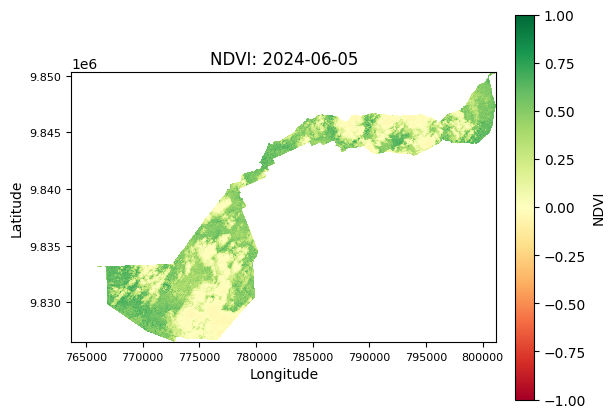

In [17]:
# Get the date string
date_str = str(ndvi_clipped.time.values[0])[:10]

# Create the plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ndvi_clipped.isel(time=0).plot(
    ax=ax,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    add_colorbar=False,
    rasterized=True,
)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("NDVI", fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Set title and aspect
ax.set_title(f"NDVI: {date_str}")
ax.set_aspect('equal', adjustable='box')

# Show the plot
plt.show()


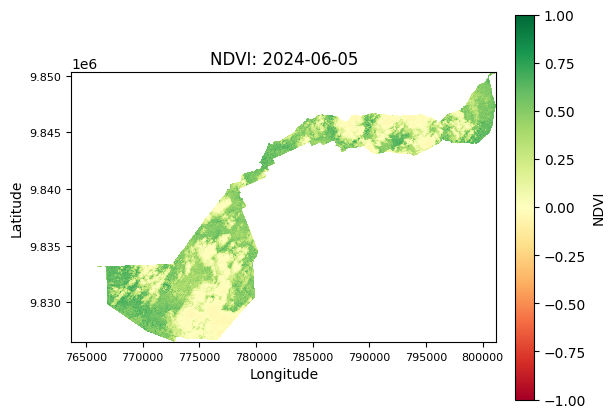

In [18]:
# Get the date string
date_str = str(savi_clipped.time.values[0])[:10]

# Create the plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ndvi_clipped.isel(time=0).plot(
    ax=ax,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    add_colorbar=False,
    rasterized=True,
)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("NDVI", fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Set title and aspect
ax.set_title(f"NDVI: {date_str}")
ax.set_aspect('equal', adjustable='box')

# Show the plot
plt.show()

### Plotting NDVI all time steps 

In [19]:
# Get number of time steps
n_times = ndvi.sizes['time']

In [20]:
# Define the subplot grid size
n_cols = 3
n_rows = math.ceil(n_times / n_cols) 

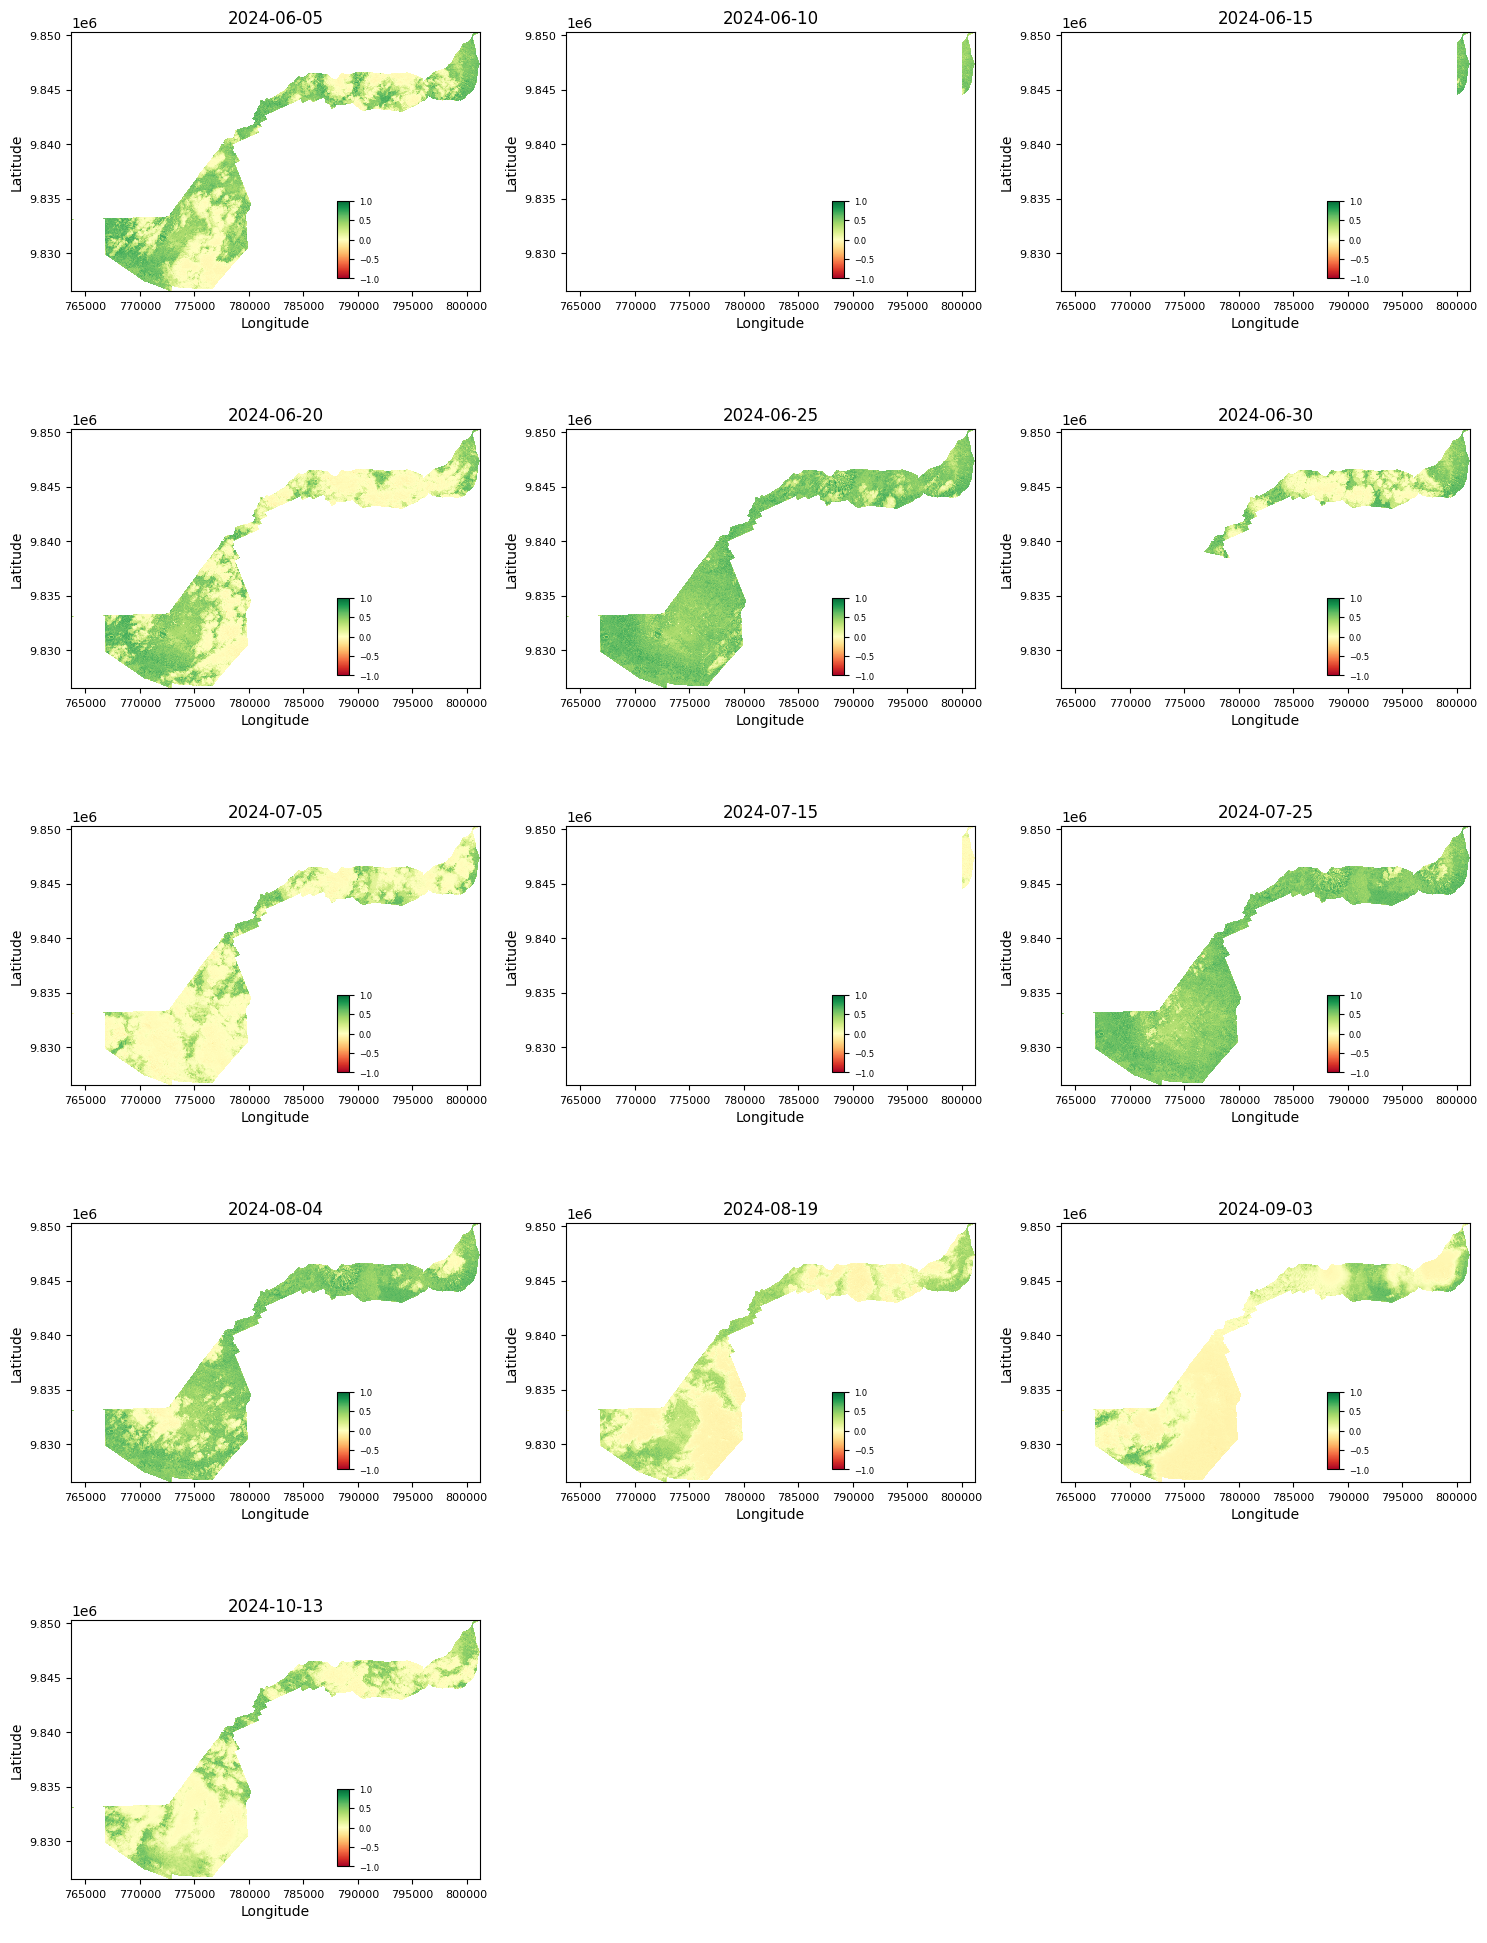

In [21]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for t in range(n_times):
    ax = axes[t]

    im = ndvi_clipped.isel(time=t).plot(
        ax=ax,
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        add_colorbar=False,
        rasterized=True,
    )
    ax.set_title(str(ndvi.time.values[t])[:10])
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # Add colorbar inside subplot
    cax = inset_axes(ax,
                     width="3%", 
                     height="30%", 
                     loc='lower left',
                     bbox_to_anchor=(0.65, 0.05, 1, 1),
                     bbox_transform=ax.transAxes,
                     borderpad=0)
    fig.colorbar(im, cax=cax, orientation='vertical')
    cax.xaxis.set_ticks_position('bottom')
    cax.tick_params(labelsize=6)

# Turn off unused subplots
for i in range(n_times, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Plotting SAVI all time steps 

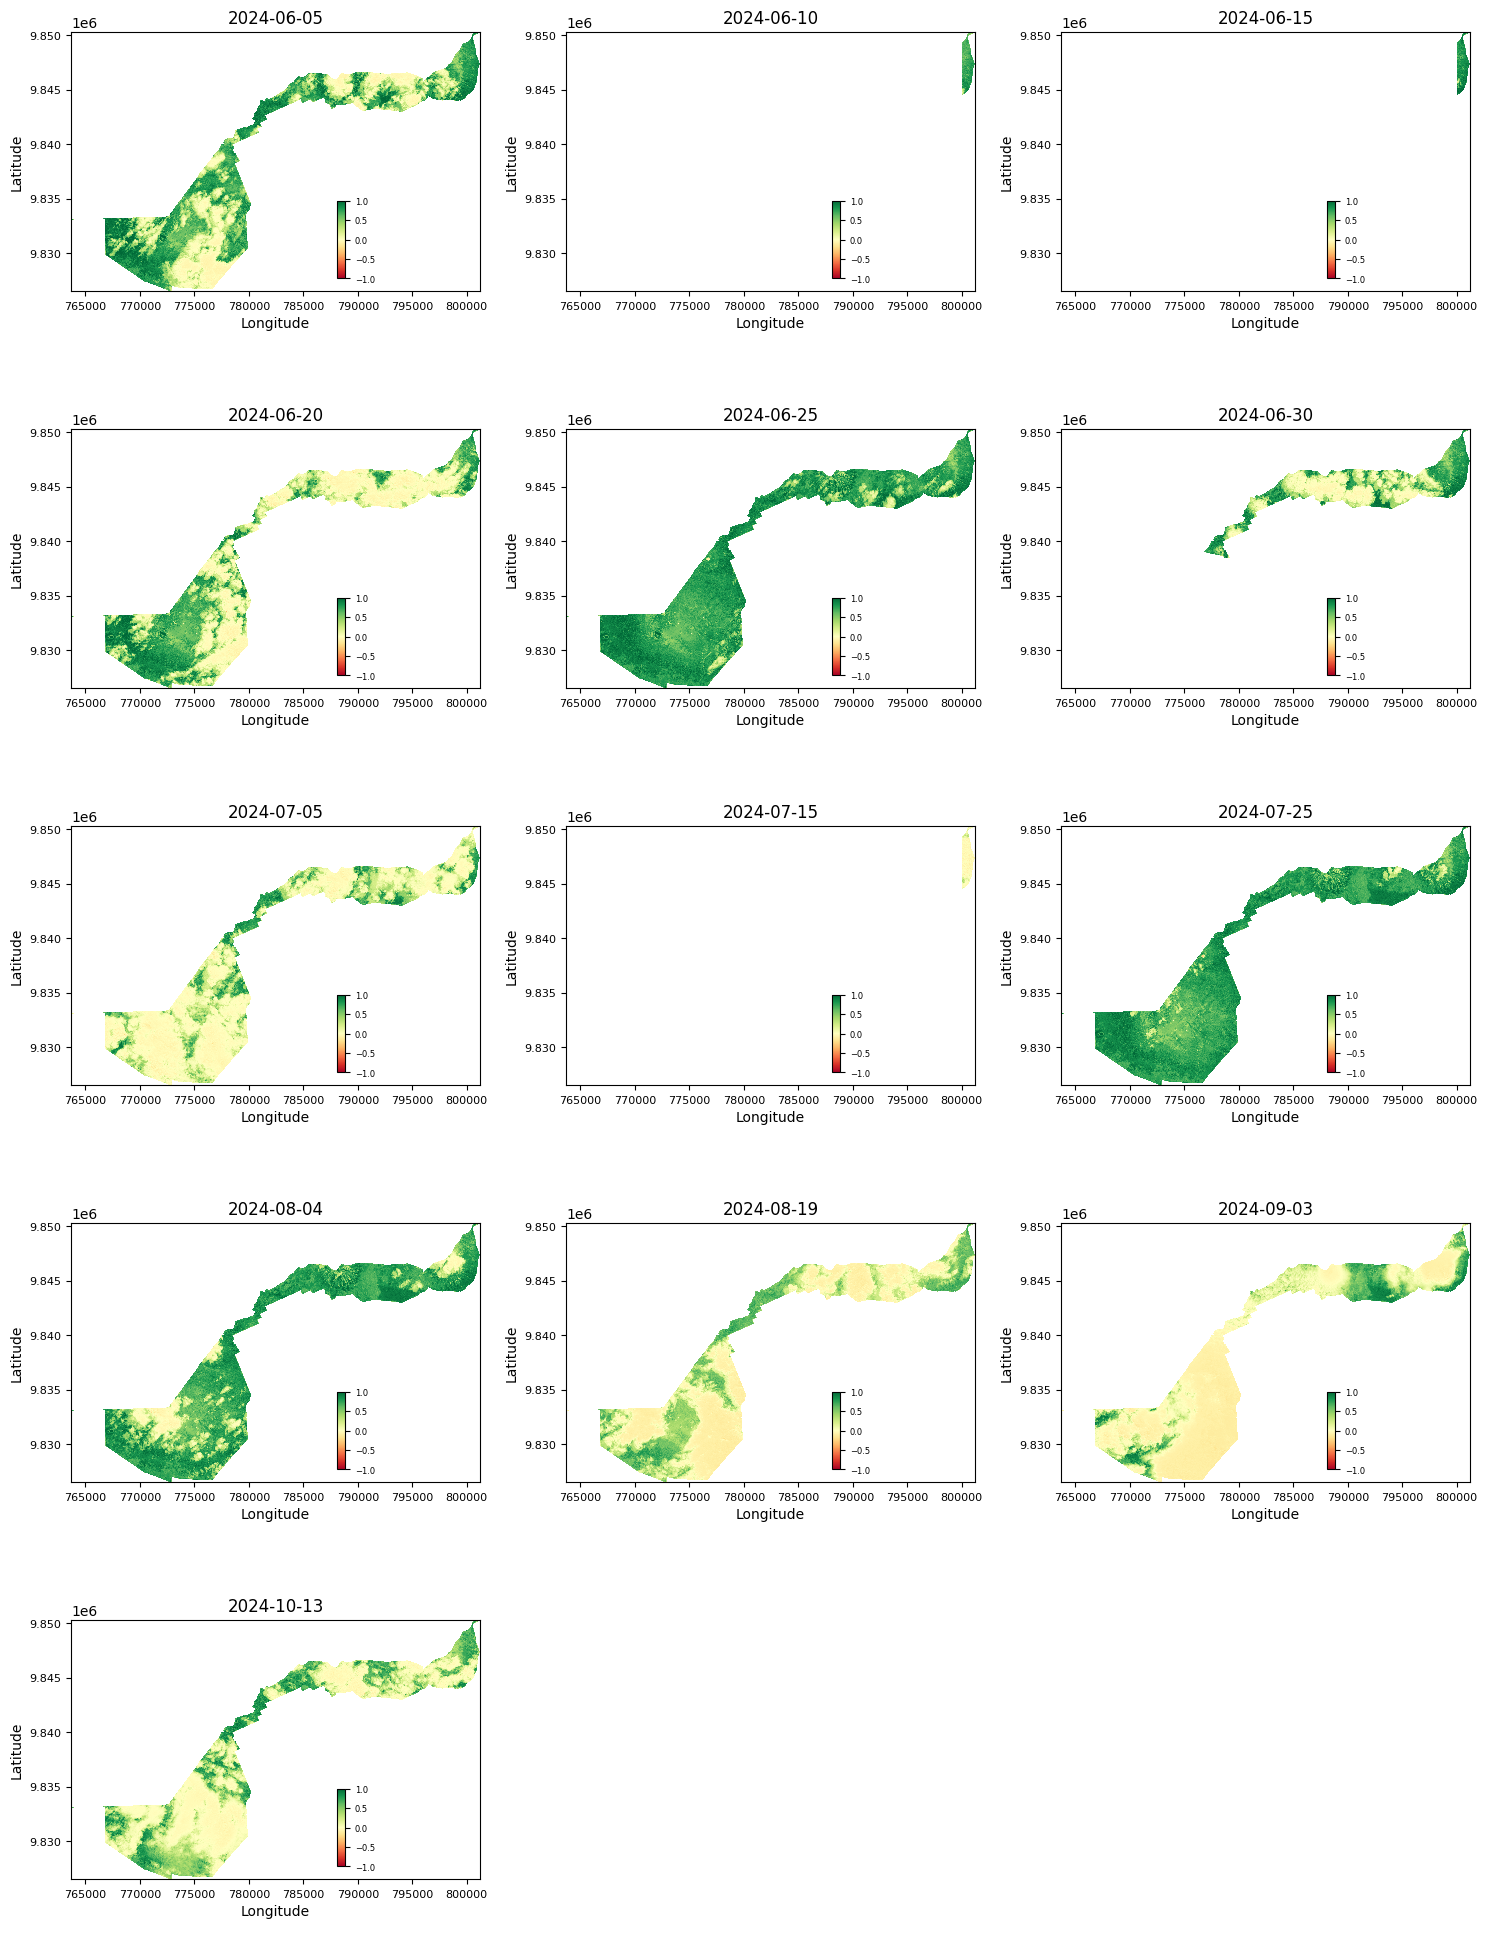

In [22]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for t in range(n_times):
    ax = axes[t]

    im = savi_clipped.isel(time=t).plot(
        ax=ax,
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        add_colorbar=False,
        rasterized=True,
    )
    ax.set_title(str(ndvi.time.values[t])[:10])
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # Add colorbar inside subplot
    cax = inset_axes(ax,
                     width="2%", 
                     height="30%",
                     loc='lower left',
                     bbox_to_anchor=(0.65, 0.05, 1, 1),
                     bbox_transform=ax.transAxes,
                     borderpad=0)
    fig.colorbar(im, cax=cax, orientation='vertical')
    cax.xaxis.set_ticks_position('bottom')
    cax.tick_params(labelsize=6)

# Turn off unused subplots
for i in range(n_times, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

##### Overall, this approach demonstrates the value of EO data cubes for advancing environmental monitoring and decision-making based on 
##### available large volume datasets.